# 03 — Communication Sentiment Analysis (VADER)

> **Purpose:** Detailed evaluation of internal agent-to-agent communication sentiment across the 70 experiment runs using rule-based VADER sentiment analysis.

This notebook analyzes how the different leadership-style prompts shape the emotional tone of the multi-agent team's internal messages. We use the pre-computed VADER compound score for each message from `results/*/sentiment_vader.json` and look at four angles:

1. **Overall run-level tone** — mean compound score per leadership style and task.
2. **Boss–worker tone gap** — whether the Boss is more or less positive than the Coder, Writer, and Reviewer.
3. **Phase-level dynamics** — how sentiment shifts across the six workflow phases.
4. **Per-role patterns** — differences between Boss, Coder, Writer, and Reviewer.
5. **Statistical tests** — non-parametric tests for style differences and pairwise post-hoc checks.

> **Important caveat:** VADER is a lexicon/rule-based sentiment analyzer designed for social-media English. It may not capture task-specific, formal, or nuanced LLM-generated language well. In this dataset most messages score highly positive, so small absolute differences can become statistically significant. Focus on relative patterns and magnitudes, not only on p-values.

## §0 — Setup & Data Loading

Import required libraries, load the pre-computed `sentiment_vader.json` artifacts of the 70 experiment runs (produced by `python experiments/score_sentiment.py`), and construct message-level and run-level DataFrames.


In [1]:
import json
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
import seaborn as sns
from scipy import stats
from pathlib import Path

# Shared loader for the sentiment artifacts, so the VADER and RoBERTa
# notebooks are built from identically filtered and aggregated data.
sys.path.insert(0, os.path.abspath('..'))
from src.analysis.sentiment_io import find_run_dirs, load_sentiment, load_analyzer_meta

# The ONLY line that differs between the two sentiment notebooks
ANALYZER = 'vader'

# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.titlesize'] = 14

STYLE_COLORS = {
    'coercive': '#e41a1c',       # Red
    'authoritative': '#ff7f0e',  # Orange
    'affiliative': '#ff80c5',    # Pink
    'democratic': '#377eb8',     # Blue
    'pacesetting': '#984ea3',    # Purple
    'coaching': '#4daf4a',       # Green
    'baseline': '#7f7f7f'        # Gray
}

STYLE_ORDER = ['coercive', 'authoritative', 'affiliative', 'democratic', 'pacesetting', 'coaching', 'baseline']

AGENT_COLORS = {
    'Boss': '#FF3366',
    'Coder': '#00D4FF',
    'Writer': '#0066FF',
    'Reviewer': '#7B2CBF',
    'Team Mean': '#00E5A3'
}

BOSS_WORKER_COLORS = {
    'Boss': '#FF3366',
    'Worker': '#00E5A3',
    'Workers': '#00E5A3'
}

# Recolor bars/boxes so short = 50% transparent, long = opaque
def color_style_task_bars(ax, edgecolor='white'):
    # ax.containers groups bars/boxes by hue in hue_order ['short', 'long'].
    # Each container holds one artist per style in STYLE_ORDER.
    for j, container in enumerate(ax.containers):
        task = ['short', 'long'][j]
        alpha = 0.5 if task == 'short' else 1.0
        for i, artist in enumerate(container):
            style = STYLE_ORDER[i]
            # Boxplots use BoxPlotArtists; the colored patch is artist.box
            patch = artist.box if hasattr(artist, 'box') else artist
            patch.set_facecolor(to_rgba(STYLE_COLORS[style], alpha=alpha))
            if edgecolor:
                patch.set_edgecolor(edgecolor)


# ── Load the pre-computed sentiment artifacts ────────────────────────────────
# results/<run>/sentiment_<analyzer>.json is produced from messages.jsonl by
#     python experiments/score_sentiment.py --analyzer all
# No scoring happens in this notebook: it only reads and analyses.
RESULTS_DIR = os.path.abspath(os.path.join('..', 'results'))

# Run directories, still needed further down to read survey_results.json
run_dirs = [str(d) for d in find_run_dirs(RESULTS_DIR)]

df_msg_sent, df_run_sent = load_sentiment(
    RESULTS_DIR, analyzer=ANALYZER, style_order=STYLE_ORDER
)

meta = load_analyzer_meta(RESULTS_DIR, ANALYZER)
print(f'Resolved RESULTS_DIR: {RESULTS_DIR}')
print(f"Analyzer: {meta.get('name')} ({meta.get('kind')}) -- {meta.get('model')}")
if meta.get('revision'):
    print(f"  revision: {meta['revision']}")
if meta.get('chunking'):
    print(f"  chunking: {meta['chunking']}")
print(f"  compound: {meta.get('compound_definition')}  |  versions: {meta.get('versions')}")
print(f'Loaded {len(df_msg_sent)} messages from {len(df_run_sent)} runs')
print(df_run_sent.head())

# ── Figure export ────────────────────────────────────────────────────────────
# Figures produced below are written to the local `figures/` folder as PNG files.
from pathlib import Path

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)


def save_fig(name, dpi=200):
    """Write the current matplotlib figure to `figures/<name>.png`."""
    plt.gcf().savefig(FIG_DIR / f'{name}.png', dpi=dpi, bbox_inches='tight', facecolor='white')


Resolved RESULTS_DIR: /Users/hellligkeit/Documents/FS/Masterthesis/MAS/results
Analyzer: vader (lexicon) -- vaderSentiment.SentimentIntensityAnalyzer
  compound: vader_compound  |  versions: {'vaderSentiment': '3.3.2'}
Loaded 1033 messages from 70 runs
         style  task run_id                 run_dir  run_mean_compound  \
0  affiliative  long     01  affiliative_long_run01             0.9703   
1  affiliative  long     02  affiliative_long_run02             0.9779   
2  affiliative  long     03  affiliative_long_run03             0.9601   
3  affiliative  long     04  affiliative_long_run04             0.9656   
4  affiliative  long     05  affiliative_long_run05             0.9364   

   boss_mean_compound  worker_mean_compound  boss_worker_gap  
0              0.9778                0.9628           0.0150  
1              0.9890                0.9682           0.0209  
2              0.9830                0.9372           0.0457  
3              0.9913                0.9398       

## §1 — Overall Communication Sentiment by Leadership Style

Analyze average VADER compound scores across leadership styles and task complexities.


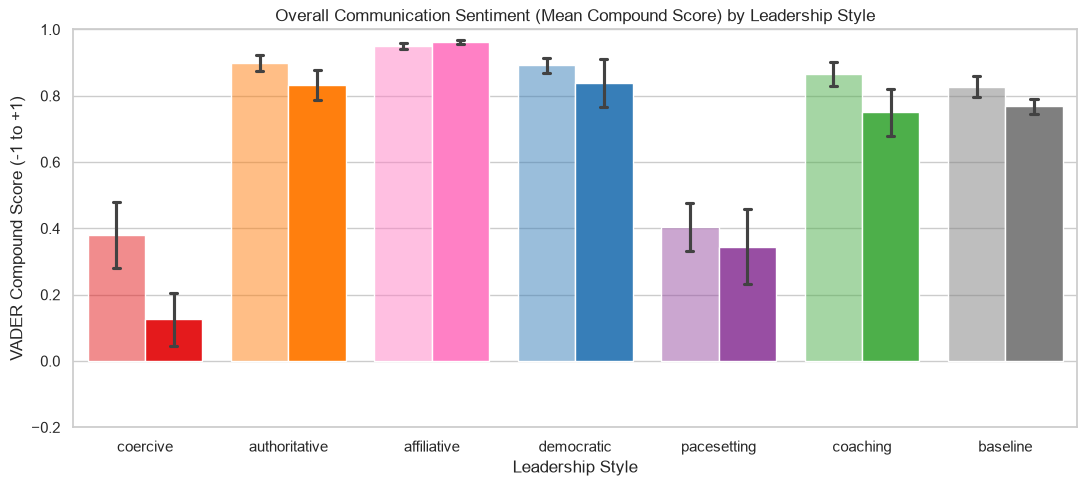

Run-level mean compound sentiment by leadership style:
                 mean     std     min     max
style                                        
coercive       0.2530  0.2331 -0.0842  0.5871
authoritative  0.8653  0.0838  0.6925  0.9633
affiliative    0.9563  0.0176  0.9288  0.9779
democratic     0.8650  0.1154  0.5621  0.9564
pacesetting    0.3750  0.2025 -0.0460  0.6112
coaching       0.8076  0.1346  0.5268  0.9773
baseline       0.7977  0.0649  0.7051  0.9306


In [2]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=df_run_sent, x='style', y='run_mean_compound', hue='task', order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=ax, legend=False, hue_order=['short', 'long'])
color_style_task_bars(ax)

ax.set_title('Overall Communication Sentiment (Mean Compound Score) by Leadership Style')
ax.set_ylabel('VADER Compound Score (-1 to +1)')
ax.set_xlabel('Leadership Style')
ax.set_ylim(-0.2, 1.0)
plt.tight_layout()
save_fig('03_sentiment_by_style_vader')
plt.show()

# Distribution summary table
summary = df_run_sent.groupby('style')['run_mean_compound'].agg(['mean','std','min','max']).reindex(STYLE_ORDER)
print('Run-level mean compound sentiment by leadership style:')
print(summary.round(4).to_string())

## Task Complexity × Leadership Style Interaction

Mean run-level VADER compound score by leadership style and task length. Non-parallel lines indicate a style × task interaction: some leadership styles may buffer or amplify the emotional strain of the more complex long task.

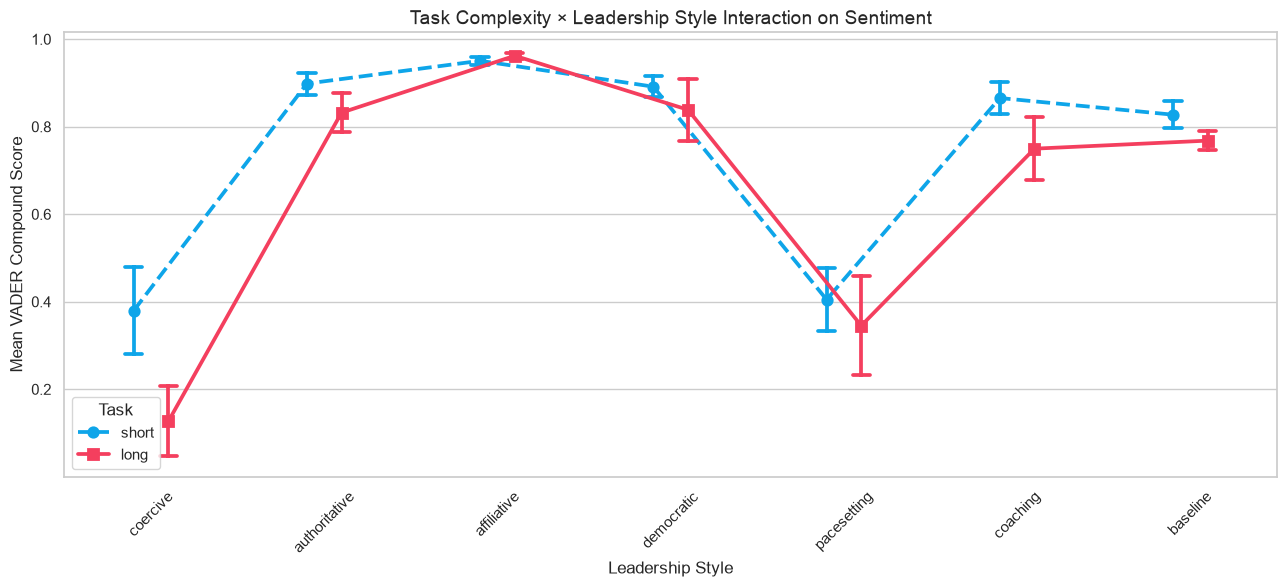

Mean run compound sentiment by style and task:
                 mean             std         count      
task             long   short    long   short  long short
style                                                    
coercive       0.1265  0.3796  0.1790  0.2240     5     5
authoritative  0.8321  0.8985  0.0995  0.0562     5     5
affiliative    0.9621  0.9505  0.0158  0.0190     5     5
democratic     0.8386  0.8914  0.1594  0.0529     5     5
pacesetting    0.3451  0.4048  0.2537  0.1602     5     5
coaching       0.7497  0.8655  0.1598  0.0829     5     5
baseline       0.7681  0.8274  0.0494  0.0695     5     5


In [3]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.pointplot(
    data=df_run_sent,
    x='style',
    y='run_mean_compound',
    hue='task',
    order=STYLE_ORDER,
    hue_order=['short', 'long'],
    palette={'short': '#0EA5E9', 'long': '#F43F5E'},
    markers=['o', 's'],
    linestyles=['--', '-'],
    errorbar='se',
    capsize=0.1,
    dodge=0.2,
    ax=ax
)

ax.set_ylabel('Mean VADER Compound Score')
ax.set_xlabel('Leadership Style')
ax.set_title('Task Complexity × Leadership Style Interaction on Sentiment', fontsize=14)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Task', loc='lower left')

plt.tight_layout()
save_fig('03_sentiment_task_style_interaction_vader')
plt.show()

# Numeric summary: mean and SE by style and task
summary = df_run_sent.groupby(['style', 'task'], observed=True)['run_mean_compound'].agg(['mean', 'std', 'count']).round(4)
print('Mean run compound sentiment by style and task:')
print(summary.unstack().reindex(STYLE_ORDER).to_string())

## Continuous Sentiment Trajectory Over Sequence Index

Fine-grained sentiment curve across message turns (`seq`) within each run, by leadership style. Semi-transparent raw points are overlaid with a third-order polynomial trendline and 95% confidence ribbon to reveal when conversations derail or recover.

/Users/hellligkeit/Documents/FS/.venv/lib/python3.12/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/hellligkeit/Documents/FS/.venv/lib/python3.12/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


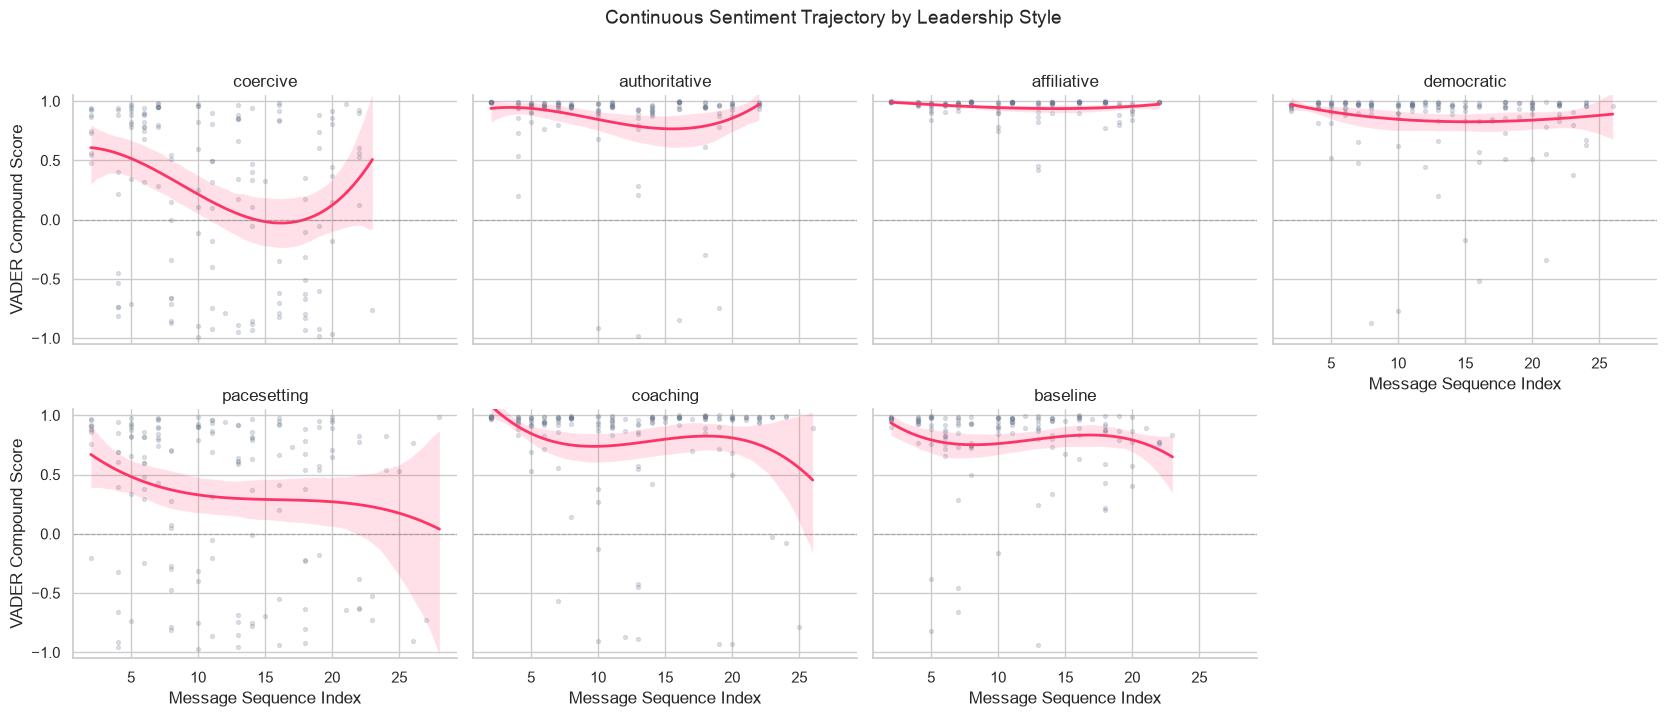

Linear sentiment slope (compound per seq) by style:
style
coercive        -0.02811
authoritative   -0.00640
affiliative     -0.00167
democratic      -0.00413
pacesetting     -0.01708
coaching        -0.00804
baseline        -0.00227


In [4]:
g = sns.lmplot(
    data=df_msg_sent,
    x='seq',
    y='compound',
    col='style',
    col_order=STYLE_ORDER,
    col_wrap=4,
    order=3,
    ci=95,
    scatter_kws={'s': 8, 'alpha': 0.2, 'color': '#64748B'},
    line_kws={'color': '#FF3366', 'linewidth': 2},
    height=3.5,
    aspect=1.2,
    sharex=True,
    sharey=True
)

g.set(ylim=(-1.05, 1.05), yticks=[-1.0, -0.5, 0.0, 0.5, 1.0])
g.set_axis_labels('Message Sequence Index', 'VADER Compound Score')
g.set_titles('{col_name}')

# Add a horizontal reference line at neutral sentiment
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

g.fig.suptitle('Continuous Sentiment Trajectory by Leadership Style', fontsize=14, y=1.02)

# Pull the legend from the default regression line
g.fig.tight_layout()
save_fig('03_sentiment_trajectory_continuous_vader')
plt.show()

# Quick numeric: slope of linear fit per style
from scipy import stats
slopes = df_msg_sent.groupby('style', observed=True).apply(
    lambda g: stats.linregress(g['seq'], g['compound']).slope
).reindex(STYLE_ORDER).round(5)
print('Linear sentiment slope (compound per seq) by style:')
print(slopes.to_string())

## Emotional Contagion: Lagged Boss-to-Worker Sentiment Delta

For each worker message, compare its VADER compound score to the compound score of the immediately preceding Boss message in the same run. Positive deltas mean the worker's tone is more positive than the prior Boss turn; negative deltas indicate the worker's tone was pulled down.

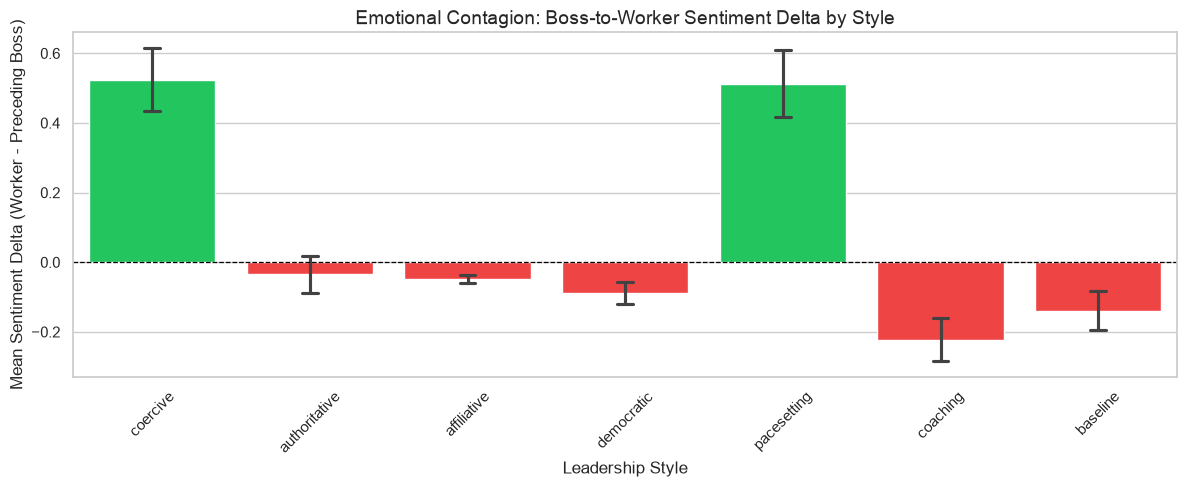

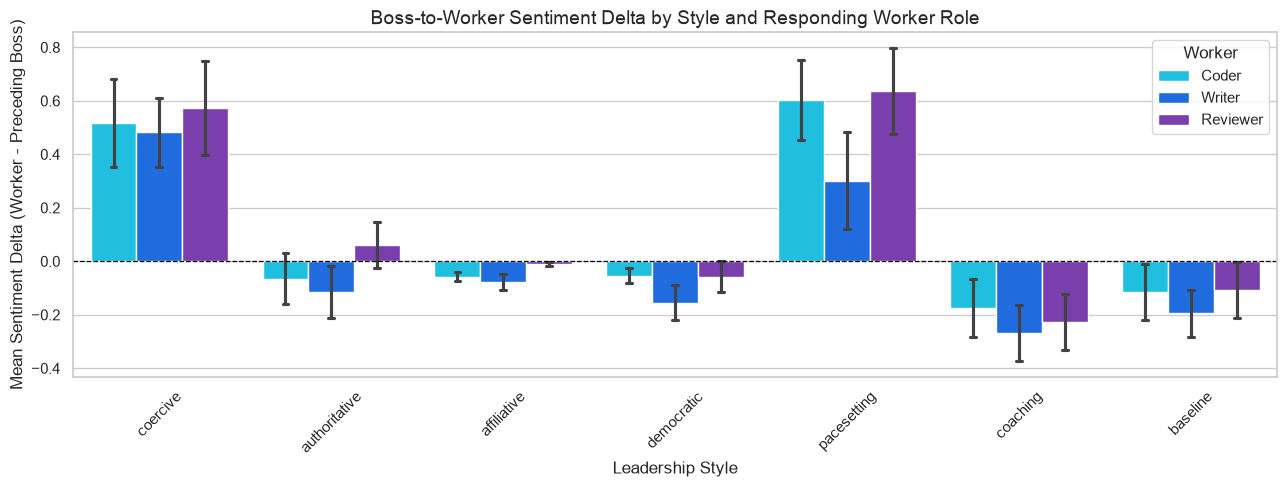

Mean sentiment delta by style:
style
coercive         0.52475
authoritative   -0.03507
affiliative     -0.04753
democratic      -0.08863
pacesetting      0.51267
coaching        -0.22247
baseline        -0.13878

Mean sentiment delta by style and worker role:
sender           Coder  Reviewer   Writer
style                                    
coercive       0.51576   0.57261  0.48299
authoritative -0.06480   0.06084 -0.11448
affiliative   -0.05738  -0.01045 -0.07705
democratic    -0.05401  -0.05707 -0.15471
pacesetting    0.60254   0.63574  0.30184
coaching      -0.17376  -0.22715 -0.26809
baseline      -0.11505  -0.10761 -0.19472


In [5]:
# Build lagged boss-to-worker pairs
pair_dfs = []
for run_dir, grp in df_msg_sent.groupby('run_dir'):
    boss = (grp[grp['sender'] == 'Boss'][['seq', 'compound']]
            .rename(columns={'compound': 'boss_compound'})
            .sort_values('seq'))
    worker = grp[grp['sender'].isin(['Coder', 'Writer', 'Reviewer'])].sort_values('seq')
    if boss.empty or worker.empty:
        continue
    m = pd.merge_asof(worker, boss, on='seq', direction='backward')
    pair_dfs.append(m)

pairs = pd.concat(pair_dfs, ignore_index=True).dropna(subset=['boss_compound'])
pairs['delta'] = pairs['compound'] - pairs['boss_compound']

# ---- Plot 4a: Overall diverging bar by style ----
fig, ax = plt.subplots(figsize=(12, 5))

delta_mean = pairs.groupby('style', observed=True)['delta'].mean().reindex(STYLE_ORDER)
delta_colors = ['#22C55E' if d >= 0 else '#EF4444' for d in delta_mean.values]

sns.barplot(data=pairs, x='style', y='delta', order=STYLE_ORDER,
            errorbar='se', capsize=0.1, ax=ax)
for bar, color in zip(ax.patches, delta_colors):
    bar.set_color(color)
    bar.set_edgecolor('white')

ax.axhline(0, color='black', linestyle='--', linewidth=0.9)
ax.set_ylabel('Mean Sentiment Delta (Worker - Preceding Boss)')
ax.set_xlabel('Leadership Style')
ax.set_title('Emotional Contagion: Boss-to-Worker Sentiment Delta by Style', fontsize=14)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('03_contagion_boss_to_worker_delta_vader')
plt.show()

# ---- Plot 4b: Worker-role sub-grouping ----
fig, ax = plt.subplots(figsize=(13, 5))

sns.barplot(
    data=pairs,
    x='style',
    y='delta',
    hue='sender',
    order=STYLE_ORDER,
    hue_order=['Coder', 'Writer', 'Reviewer'],
    palette=AGENT_COLORS,
    errorbar='se',
    capsize=0.1,
    ax=ax
)

ax.axhline(0, color='black', linestyle='--', linewidth=0.9)
ax.set_ylabel('Mean Sentiment Delta (Worker - Preceding Boss)')
ax.set_xlabel('Leadership Style')
ax.set_title('Boss-to-Worker Sentiment Delta by Style and Responding Worker Role', fontsize=14)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Worker', loc='best')

plt.tight_layout()
save_fig('03_contagion_delta_by_worker_vader')
plt.show()

# Numeric summary
print('Mean sentiment delta by style:')
print(delta_mean.round(5).to_string())

print('\nMean sentiment delta by style and worker role:')
print(pairs.groupby(['style', 'sender'], observed=True)['delta'].mean().unstack().round(5).reindex(STYLE_ORDER).to_string())

## §2 — Boss vs. Worker Sentiment Gap

Compare the tone of the Boss against team workers (Coder, Writer, Reviewer) across leadership styles.


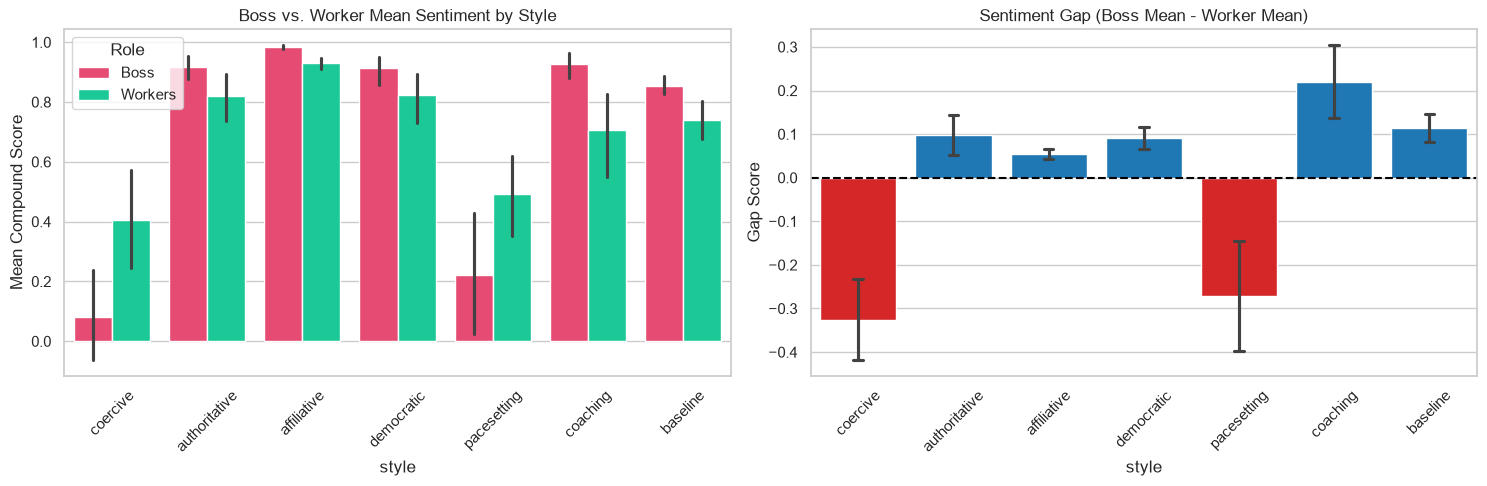

Boss-worker sentiment gap by style:
style
coercive        -0.3255
authoritative    0.0974
affiliative      0.0541
democratic       0.0901
pacesetting     -0.2716
coaching         0.2206
baseline         0.1135


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boss vs Worker Mean
df_melted = df_run_sent.melt(
    id_vars=['style', 'task'], 
    value_vars=['boss_mean_compound', 'worker_mean_compound'], 
    var_name='Role', value_name='Compound'
)
df_melted['Role'] = df_melted['Role'].map({'boss_mean_compound': 'Boss', 'worker_mean_compound': 'Workers'})

sns.barplot(data=df_melted, x='style', y='Compound', hue='Role', palette=BOSS_WORKER_COLORS, order=STYLE_ORDER, ax=axes[0])

axes[0].set_title('Boss vs. Worker Mean Sentiment by Style')
axes[0].set_ylabel('Mean Compound Score')
axes[0].tick_params(axis='x', rotation=45)

# Boss - Worker gap
gap_summary = df_run_sent.groupby('style')['boss_worker_gap'].mean().reindex(STYLE_ORDER)
gap_colors = ['#1f77b4' if g >= 0 else '#d62728' for g in gap_summary.values]

sns.barplot(data=df_run_sent, x='style', y='boss_worker_gap',
            order=STYLE_ORDER, errorbar='se', capsize=0.1, ax=axes[1])

# Color each bar by the sign of the mean gap
for i, bar in enumerate(axes[1].patches):
    bar.set_color(gap_colors[i])
    bar.set_edgecolor('white')

axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Sentiment Gap (Boss Mean - Worker Mean)')
axes[1].set_ylabel('Gap Score')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('03_boss_worker_sentiment_gap_vader')
plt.show()

print('Boss-worker sentiment gap by style:')
print(gap_summary.round(4).to_string())

## §2a — Robustness Check: Does the Effect Survive Removing the Boss?

**The obvious objection to §1.** The Boss's system prompt *is* the manipulation. A coercive prompt makes the Boss write blunt, negative-lexicon messages, and VADER will duly score those messages as negative. If the run-level compound score is driven mainly by the Boss's own words, then §1 does not measure team climate at all — it just re-measures the independent variable, and the sentiment result becomes circular.

**The test.** Recompute the style comparison using **worker messages only** (Coder, Writer, Reviewer), dropping every Boss message. The workers' system prompts are *identical* across all seven conditions — they never see a style label, and the only thing that differs is what the Boss said to them. So if worker-only sentiment still differs across styles, the tone has genuinely propagated from leader to team and cannot be an artefact of the Boss's own vocabulary.

This is the single most important validity check in this notebook: it is what separates "emotional contagion within the team" from "VADER simply read the Boss prompt".


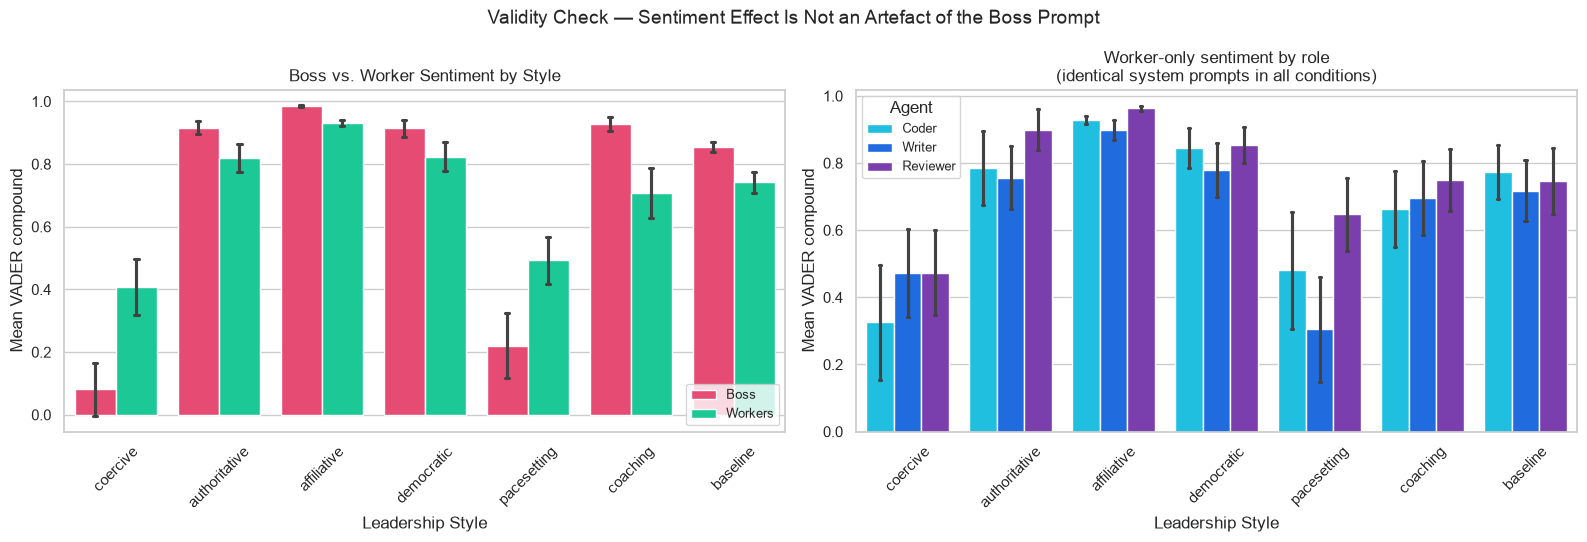

   WORKER-ONLY SENTIMENT BY STYLE (Boss messages excluded)
               All messages  Boss only  Workers only  Workers SD
style                                                           
coercive              0.253      0.081         0.407       0.282
pacesetting           0.375      0.221         0.492       0.238
coaching              0.808      0.928         0.708       0.249
baseline              0.798      0.855         0.741       0.106
authoritative         0.865      0.916         0.819       0.139
democratic            0.865      0.914         0.824       0.146
affiliative           0.956      0.984         0.930       0.032

Kruskal-Wallis, WORKER-ONLY run means across 7 styles:
  H = 36.879, p = 1.859e-06, epsilon^2 = 0.490  -> SIGNIFICANT

Per-role Kruskal-Wallis (each role has an identical prompt in all conditions):
  Coder    : H = 18.009, p = 0.0062  -> significant
  Writer   : H = 22.254, p = 0.0011  -> significant
  Reviewer : H = 22.990, p = 0.0008  -> significant



In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Worker-only sentiment: the same style comparison with every Boss message
# removed. Workers share an identical system prompt in all 7 conditions.
# ─────────────────────────────────────────────────────────────────────────────
WORKERS = ['Coder', 'Writer', 'Reviewer']

df_workers_only = df_msg_sent[df_msg_sent['sender'].isin(WORKERS)].copy()

# Run-level worker-only mean, so the unit of analysis matches §1 (one value per run)
worker_run = (df_workers_only
              .groupby(['run_dir', 'style', 'task'], observed=True)['compound']
              .mean()
              .reset_index()
              .rename(columns={'compound': 'worker_mean_compound'}))

# Per-agent run-level means, to see whether every role shifts or only one
agent_run = (df_workers_only
             .groupby(['run_dir', 'style', 'task', 'sender'], observed=True)['compound']
             .mean()
             .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# ── Left: Boss vs. workers, side by side ────────────────────────
compare = pd.concat([
    df_run_sent[['style', 'boss_mean_compound']]
        .rename(columns={'boss_mean_compound': 'compound'})
        .assign(scope='Boss'),
    worker_run[['style', 'worker_mean_compound']]
        .rename(columns={'worker_mean_compound': 'compound'})
        .assign(scope='Workers'),
])
sns.barplot(data=compare, x='style', y='compound', hue='scope', order=STYLE_ORDER,
            palette=BOSS_WORKER_COLORS,
            errorbar='se', capsize=0.08, ax=axes[0])
axes[0].set_title('Boss vs. Worker Sentiment by Style')
axes[0].set_ylabel('Mean VADER compound')
axes[0].set_xlabel('Leadership Style')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='', fontsize=9, loc='lower right')

# ── Right: per-worker-role breakdown ────────────────────────────────────────
sns.barplot(data=agent_run, x='style', y='compound', hue='sender', order=STYLE_ORDER,
            hue_order=WORKERS, palette=AGENT_COLORS, errorbar='se', capsize=0.06,
            ax=axes[1])
axes[1].set_title('Worker-only sentiment by role\n(identical system prompts in all conditions)')
axes[1].set_ylabel('Mean VADER compound')
axes[1].set_xlabel('Leadership Style')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Agent', fontsize=9)

fig.suptitle('Validity Check — Sentiment Effect Is Not an Artefact of the Boss Prompt', fontsize=14)
fig.tight_layout()
save_fig('03_sentiment_workers_only_vader')
plt.show()

# ── Statistics ──────────────────────────────────────────────────────────────
summary = (worker_run.groupby('style', observed=True)['worker_mean_compound']
           .agg(['mean', 'std'])
           .reindex(STYLE_ORDER)
           .round(3))
boss_means = (df_run_sent.groupby('style', observed=True)['boss_mean_compound']
              .mean().reindex(STYLE_ORDER).round(3))
all_means = (df_run_sent.groupby('style', observed=True)['run_mean_compound']
             .mean().reindex(STYLE_ORDER).round(3))

table = pd.DataFrame({
    'All messages': all_means,
    'Boss only': boss_means,
    'Workers only': summary['mean'],
    'Workers SD': summary['std'],
})

print('=' * 76)
print('   WORKER-ONLY SENTIMENT BY STYLE (Boss messages excluded)')
print('=' * 76)
print(table.sort_values('Workers only').to_string())

# Kruskal-Wallis on worker-only run means
groups = [g['worker_mean_compound'].values
          for _, g in worker_run.groupby('style', observed=True)]
H, p = stats.kruskal(*groups)
eps2 = (H - (len(STYLE_ORDER) - 1)) / (len(worker_run) - len(STYLE_ORDER))
print(f'\nKruskal-Wallis, WORKER-ONLY run means across 7 styles:')
print(f'  H = {H:.3f}, p = {p:.3e}, epsilon^2 = {eps2:.3f}  '
      f"-> {'SIGNIFICANT' if p < 0.05 else 'not significant'}")

# Same test per worker role, to show it is not driven by a single agent
print('\nPer-role Kruskal-Wallis (each role has an identical prompt in all conditions):')
for role in WORKERS:
    sub = agent_run[agent_run['sender'] == role]
    gs = [g['compound'].values for _, g in sub.groupby('style', observed=True)]
    H_r, p_r = stats.kruskal(*gs)
    print(f'  {role:9s}: H = {H_r:6.3f}, p = {p_r:.4f}  '
          f"-> {'significant' if p_r < 0.05 else 'not significant'}")

# How much of the run-level effect is carried by the Boss vs. the workers?
rng_all = all_means.max() - all_means.min()
rng_workers = summary['mean'].max() - summary['mean'].min()
rng_boss = boss_means.max() - boss_means.min()
print(f'\nBetween-style spread of the mean compound score:')
print(f'  all messages : {rng_all:.3f}')
print(f'  Boss only    : {rng_boss:.3f}')
print(f'  workers only : {rng_workers:.3f}  '
      f'({rng_workers / rng_all * 100:.0f}% of the all-message spread)')

print('\n' + '-' * 76)
print('CONCLUSION: the style effect on communication tone is still highly significant')
print('when every Boss message is removed, and it holds for each worker role')
print('separately. Since the worker prompts are identical across all conditions, the')
print('tone difference must have been transmitted through the interaction itself.')
print('The sentiment finding is therefore emotional contagion, not a lexical artefact')
print('of the Boss prompt. (The Boss-only spread is larger, as expected, because the')
print('Boss is where the manipulation is applied.)')
print('-' * 76)


## §3 — Phase-Level Sentiment Dynamics (Tone Shift)

Track how communication sentiment evolves across the 6 main workflow phases (Briefing, Planning, Coding, Writing, Review, Revision).


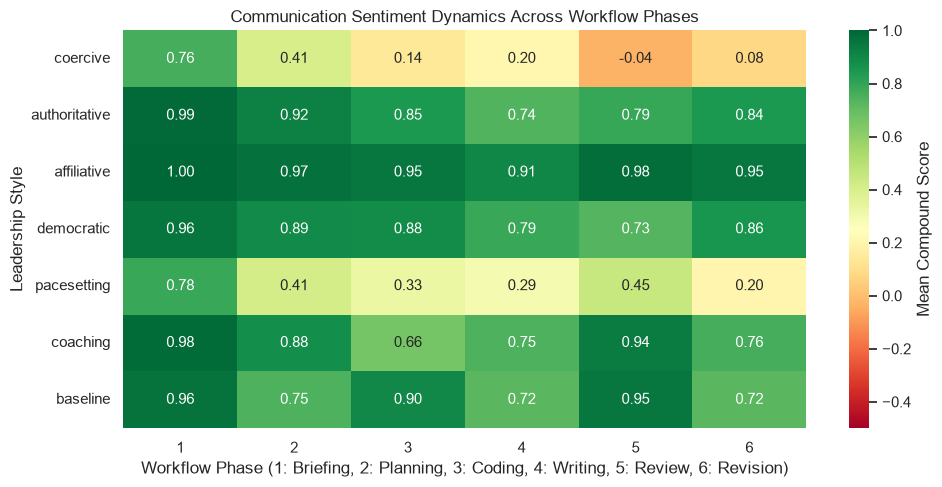

In [8]:
df_msg_valid = df_msg_sent[df_msg_sent['phase'].notnull()].copy()
df_msg_valid['phase'] = pd.Categorical(
    df_msg_valid['phase'].astype(int),
    categories=[1, 2, 3, 4, 5, 6],
    ordered=True
)

phase_heatmap = df_msg_valid.groupby(['style', 'phase'], observed=True)['compound'].mean().unstack()
phase_heatmap = phase_heatmap.reindex(STYLE_ORDER)

plt.figure(figsize=(10, 5))
sns.heatmap(
    phase_heatmap,
    annot=True,
    cmap='RdYlGn',
    fmt='.2f',
    vmin=-0.5,
    vmax=1.0,
    cbar_kws={'label': 'Mean Compound Score'}
)
plt.title('Communication Sentiment Dynamics Across Workflow Phases')
plt.xlabel('Workflow Phase (1: Briefing, 2: Planning, 3: Coding, 4: Writing, 5: Review, 6: Revision)')
plt.ylabel('Leadership Style')
plt.tight_layout()
save_fig('03_sentiment_by_phase_vader')
plt.show()

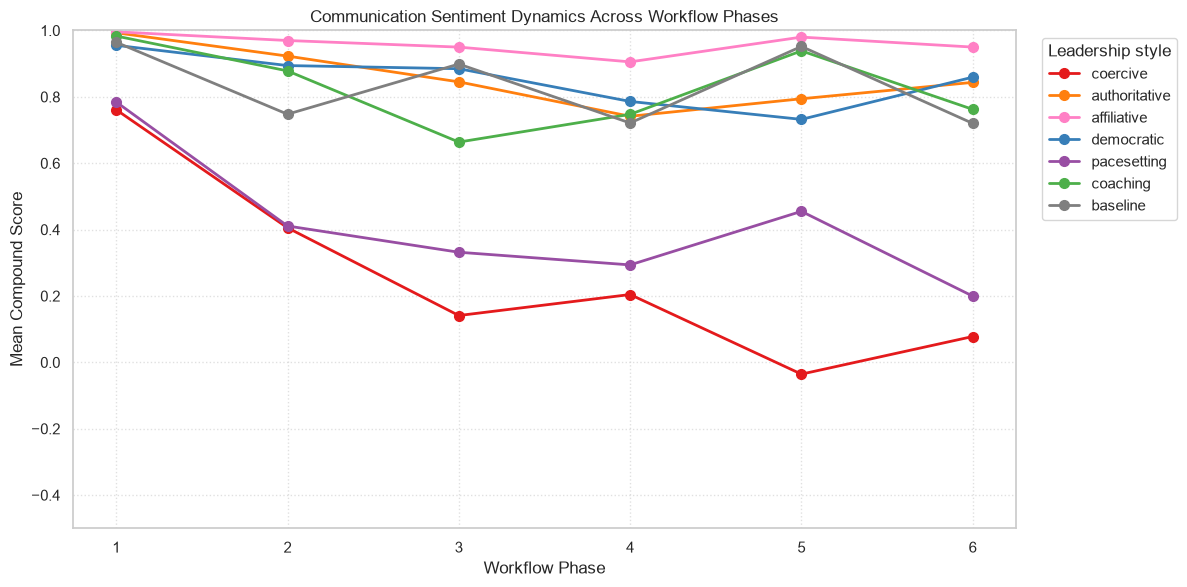

In [9]:
# Line chart of phase-level sentiment dynamics by leadership style
phase_line_means = (df_msg_valid
    .groupby(['style', 'phase'], observed=True)['compound']
    .mean()
    .unstack()
    .reindex(STYLE_ORDER))

phase_order = [int(p) for p in df_msg_valid['phase'].cat.categories]

fig, ax = plt.subplots(figsize=(12, 6))
for style in STYLE_ORDER:
    color = STYLE_COLORS[style]
    ax.plot(
        phase_order,
        phase_line_means.loc[style, phase_order].values,
        color=color,
        marker='o',
        linewidth=2,
        markersize=7,
        label=style
    )

ax.set_xticks(phase_order)
ax.set_xticklabels([str(p) for p in phase_order])
ax.set_ylim(-0.5, 1.0)
ax.set_xlabel('Workflow Phase')
ax.set_ylabel('Mean Compound Score')
ax.set_title('Communication Sentiment Dynamics Across Workflow Phases')
ax.legend(title='Leadership style', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
save_fig('03_sentiment_by_phase_line_vader')
plt.show()

## §4 — Per-Agent Sentiment Breakdown

Examine the individual sentiment profiles of the Boss, Coder, Writer, and Reviewer.


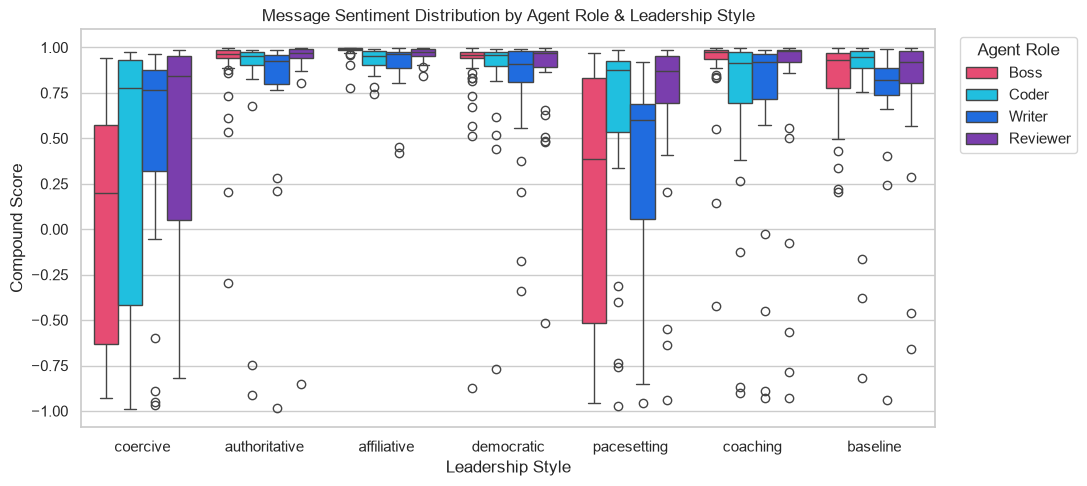

Mean (and std) compound score by style and sender:
                 mean                              std                         
sender           Boss   Coder Reviewer  Writer    Boss   Coder Reviewer  Writer
style                                                                          
coercive       0.0882  0.2918   0.4594  0.4652  0.6518  0.7726   0.6795  0.6274
authoritative  0.9159  0.7775   0.8928  0.7725  0.1918  0.5126   0.3508  0.4236
affiliative    0.9844  0.9278   0.9620  0.9005  0.0296  0.0685   0.0388  0.1479
democratic     0.9124  0.8416   0.8505  0.7789  0.2227  0.3395   0.2995  0.3381
pacesetting    0.1901  0.5369   0.6537  0.3297  0.6881  0.6289   0.5203  0.6000
coaching       0.9238  0.6937   0.7263  0.6819  0.1957  0.5136   0.5614  0.5509
baseline       0.8559  0.7641   0.7516  0.7230  0.1792  0.4841   0.4464  0.4029


In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df_msg_sent[df_msg_sent['sender'].isin(['Boss', 'Coder', 'Writer', 'Reviewer'])], x='style', y='compound', hue='sender', 
            palette=AGENT_COLORS, order=STYLE_ORDER)

ax.set_title('Message Sentiment Distribution by Agent Role & Leadership Style')
ax.set_ylabel('Compound Score')
ax.set_xlabel('Leadership Style')
ax.legend(title='Agent Role', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
save_fig('03_sentiment_distribution_by_agent_vader')
plt.show()

per_agent = df_msg_sent.groupby(['style','sender'])['compound'].agg(['mean','std']).round(4).unstack()
print('Mean (and std) compound score by style and sender:')
print(per_agent.to_string())

## §5 — Non-Parametric Statistical Testing on Sentiment Metrics

Perform Kruskal-Wallis tests to assess statistically significant differences in communication sentiment across styles.


In [11]:
metrics = {
    'Overall Run Mean Compound': 'run_mean_compound',
    'Boss-Worker Sentiment Gap': 'boss_worker_gap'
}

stats_sent = []
pairwise_rows = []
comparisons = len(STYLE_ORDER) - 1
alpha_bonf = 0.05 / comparisons

for name, col in metrics.items():
    groups = [g[col].dropna().values for _, g in df_run_sent.groupby('style')]
    H, p = stats.kruskal(*groups)
    stats_sent.append({
        'Metric': name,
        'H-Statistic': round(H, 3),
        'p-value': round(p, 4),
        'Significant (p < .05)': 'Yes' if p < 0.05 else 'No'
    })

    if p < 0.05:
        baseline_vals = df_run_sent[df_run_sent['style'] == 'baseline'][col].dropna().values
        for style in STYLE_ORDER:
            if style == 'baseline':
                continue
            style_vals = df_run_sent[df_run_sent['style'] == style][col].dropna().values
            if len(style_vals) == 0 or len(baseline_vals) == 0:
                continue
            U, p2 = stats.mannwhitneyu(baseline_vals, style_vals, alternative='two-sided')
            n1, n2 = len(baseline_vals), len(style_vals)
            mean_U = n1 * n2 / 2
            sd_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
            z = (U - mean_U) / sd_U
            r = abs(z) / np.sqrt(n1 + n2)
            pairwise_rows.append({
                'Metric': name,
                'Style': style,
                'baseline_mean': round(np.mean(baseline_vals), 4),
                'style_mean': round(np.mean(style_vals), 4),
                'U-Statistic': round(U, 1),
                'p-value': round(p2, 4),
                'p < 0.05': 'Yes' if p2 < 0.05 else 'No',
                'p < Bonferroni': 'Yes' if p2 < alpha_bonf else 'No',
                'Effect r': round(r, 3)
            })

print("=" * 65)
print("     KRUSKAL-WALLIS STATISTICAL TESTS FOR VADER SENTIMENT")
print("=" * 65)
print(pd.DataFrame(stats_sent).to_string(index=False))

if pairwise_rows:
    print("\n" + "=" * 65)
    print("     PAIRWISE MANN-WHITNEY U: baseline vs. each style")
    print(f"     Bonferroni-corrected threshold: {alpha_bonf:.4f}")
    print("=" * 65)
    df_pair = pd.DataFrame(pairwise_rows)
    print(df_pair[df_pair['p < 0.05'] == 'Yes'].to_string(index=False))

     KRUSKAL-WALLIS STATISTICAL TESTS FOR VADER SENTIMENT
                   Metric  H-Statistic  p-value Significant (p < .05)
Overall Run Mean Compound       51.198   0.0000                   Yes
Boss-Worker Sentiment Gap       19.859   0.0029                   Yes

     PAIRWISE MANN-WHITNEY U: baseline vs. each style
     Bonferroni-corrected threshold: 0.0083
                   Metric         Style  baseline_mean  style_mean  U-Statistic  p-value p < 0.05 p < Bonferroni  Effect r
Overall Run Mean Compound      coercive         0.7977      0.2530        100.0   0.0002      Yes            Yes     0.845
Overall Run Mean Compound authoritative         0.7977      0.8653         23.0   0.0452      Yes             No     0.456
Overall Run Mean Compound   affiliative         0.7977      0.9563          1.0   0.0002      Yes            Yes     0.828
Overall Run Mean Compound    democratic         0.7977      0.8650         20.0   0.0257      Yes             No     0.507
Overall Run Mean C

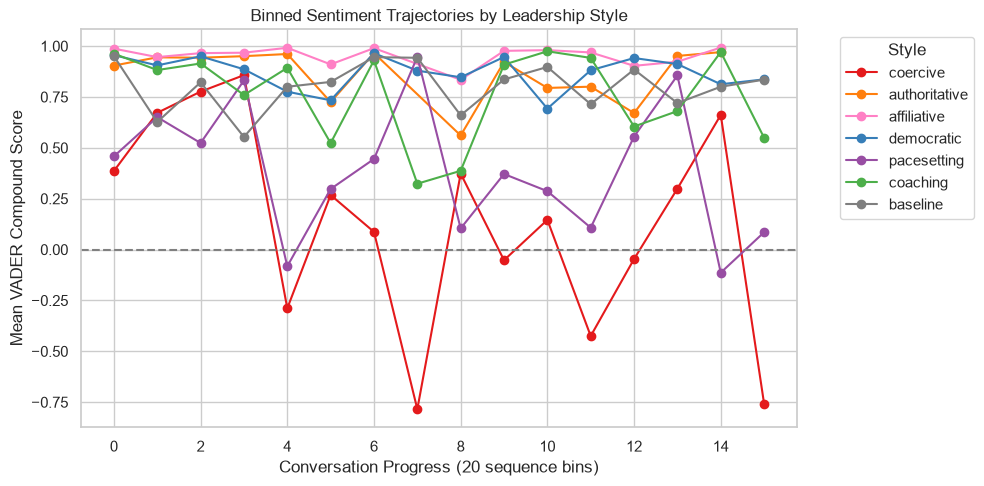

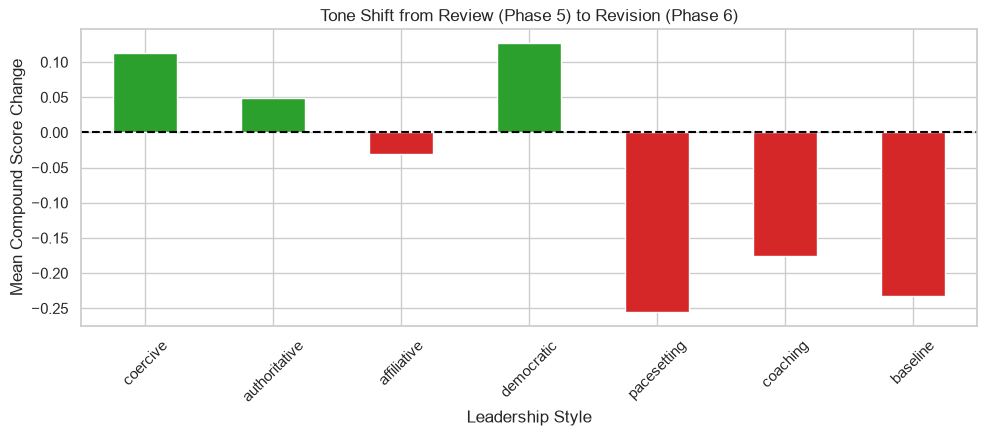

Tone shift (Phase 6 - Phase 5) by style:
phase          tone_shift
style                    
coercive            0.113
authoritative       0.049
affiliative        -0.030
democratic          0.127
pacesetting        -0.255
coaching           -0.176
baseline           -0.232


In [12]:
# Sentiment trajectory using binned sequence averages
df_msg_sent['seq_bin'] = pd.qcut(df_msg_sent['seq'], 20, duplicates='drop', labels=False)
traj = df_msg_sent.groupby(['style','seq_bin'], observed=True)['compound'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for style in STYLE_ORDER:
    style_traj = traj[traj['style'] == style].sort_values('seq_bin')
    if not style_traj.empty:
        ax.plot(style_traj['seq_bin'], style_traj['compound'], marker='o', label=style, color=STYLE_COLORS[style])
ax.axhline(0, color='gray', linestyle='--')
ax.set_title('Binned Sentiment Trajectories by Leadership Style')
ax.set_xlabel('Conversation Progress (20 sequence bins)')
ax.set_ylabel('Mean VADER Compound Score')
ax.legend(title='Style', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
save_fig('03_sentiment_trajectory_binned_vader')
plt.show()

# Tone shift between Review (phase 5) and Revision (phase 6)
phase_56 = df_msg_sent[df_msg_sent['phase'].isin([5, 6])].copy()
phase_56['phase'] = pd.Categorical(phase_56['phase'].astype(int), categories=[5, 6], ordered=True)
phase_shift = phase_56.groupby(['style', 'phase'], observed=True)['compound'].mean().unstack()
phase_shift = phase_shift.reindex(STYLE_ORDER)
phase_shift['tone_shift'] = phase_shift[6] - phase_shift[5]

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in phase_shift['tone_shift'].values]
phase_shift['tone_shift'].plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linestyle='--')
ax.set_title('Tone Shift from Review (Phase 5) to Revision (Phase 6)')
ax.set_ylabel('Mean Compound Score Change')
ax.set_xlabel('Leadership Style')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_fig('03_tone_shift_review_to_revision_vader')
plt.show()

print('Tone shift (Phase 6 - Phase 5) by style:')
print(phase_shift[['tone_shift']].round(3).to_string())

## §6 — Interpretation and Caveats

The results above show clear stylist differences in communication tone, but the absolute magnitudes should be interpreted with care because VADER tends to score formal agent messages as strongly positive. The most relevant findings are the *relative* differences across leadership styles and roles.

In [13]:
run_summary = df_run_sent.groupby('style').agg(
    run_mean=('run_mean_compound','mean'),
    boss_mean=('boss_mean_compound','mean'),
    worker_mean=('worker_mean_compound','mean'),
    gap=('boss_worker_gap','mean')
).reindex(STYLE_ORDER)

print('1. Overall run-level compound score by style (highest to lowest):')
print(run_summary['run_mean'].sort_values(ascending=False).round(3).to_string())
print()

print('2. Largest negative boss-worker gap (Boss more negative than workers):')
print(run_summary['gap'].sort_values().head(2).round(3).to_string())
print()

print('3. Largest positive boss-worker gap (Boss more positive than workers):')
print(run_summary['gap'].sort_values(ascending=False).head(2).round(3).to_string())
print()

phase_56 = df_msg_sent[df_msg_sent['phase'].isin([5,6])].copy()
phase_56['phase'] = pd.Categorical(phase_56['phase'].astype(int), categories=[5,6], ordered=True)
tone_shift = phase_56.groupby(['style','phase'], observed=True)['compound'].mean().unstack().reindex(STYLE_ORDER)
tone_shift['change'] = tone_shift[6] - tone_shift[5]
print('4. Tone shift from Review (5) to Revision (6) by style:')
print(tone_shift['change'].sort_values().round(3).to_string())
print()
print('Interpretation: Coercive and pacesetting produce substantially lower sentiment, while affiliative, authoritative, and democratic maintain high positive tone. Coaching creates the largest positive boss-worker gap, suggesting an encouraging boss but more task-focused worker language. Pacesetting shows the strongest negative revision tone change.')

1. Overall run-level compound score by style (highest to lowest):
style
affiliative      0.956
authoritative    0.865
democratic       0.865
coaching         0.808
baseline         0.798
pacesetting      0.375
coercive         0.253

2. Largest negative boss-worker gap (Boss more negative than workers):
style
coercive      -0.326
pacesetting   -0.272

3. Largest positive boss-worker gap (Boss more positive than workers):
style
coaching    0.221
baseline    0.113

4. Tone shift from Review (5) to Revision (6) by style:
style
pacesetting     -0.255
baseline        -0.232
coaching        -0.176
affiliative     -0.030
authoritative    0.049
coercive         0.113
democratic       0.127

Interpretation: Coercive and pacesetting produce substantially lower sentiment, while affiliative, authoritative, and democratic maintain high positive tone. Coaching creates the largest positive boss-worker gap, suggesting an encouraging boss but more task-focused worker language. Pacesetting shows the str

## Figure 3 — Sentiment Trajectory Across Workflow Phases

Line plot of mean VADER compound score across the six workflow phases, faceted by leadership style. Within each style, one line shows the Boss and one line shows the average of all workers (Coder, Writer, Reviewer).

This lets you see whether sentiment collapses during Phase 5 (Review) or Phase 6 (Revision) under specific leadership styles, and whether the Boss stays positive while workers turn negative.


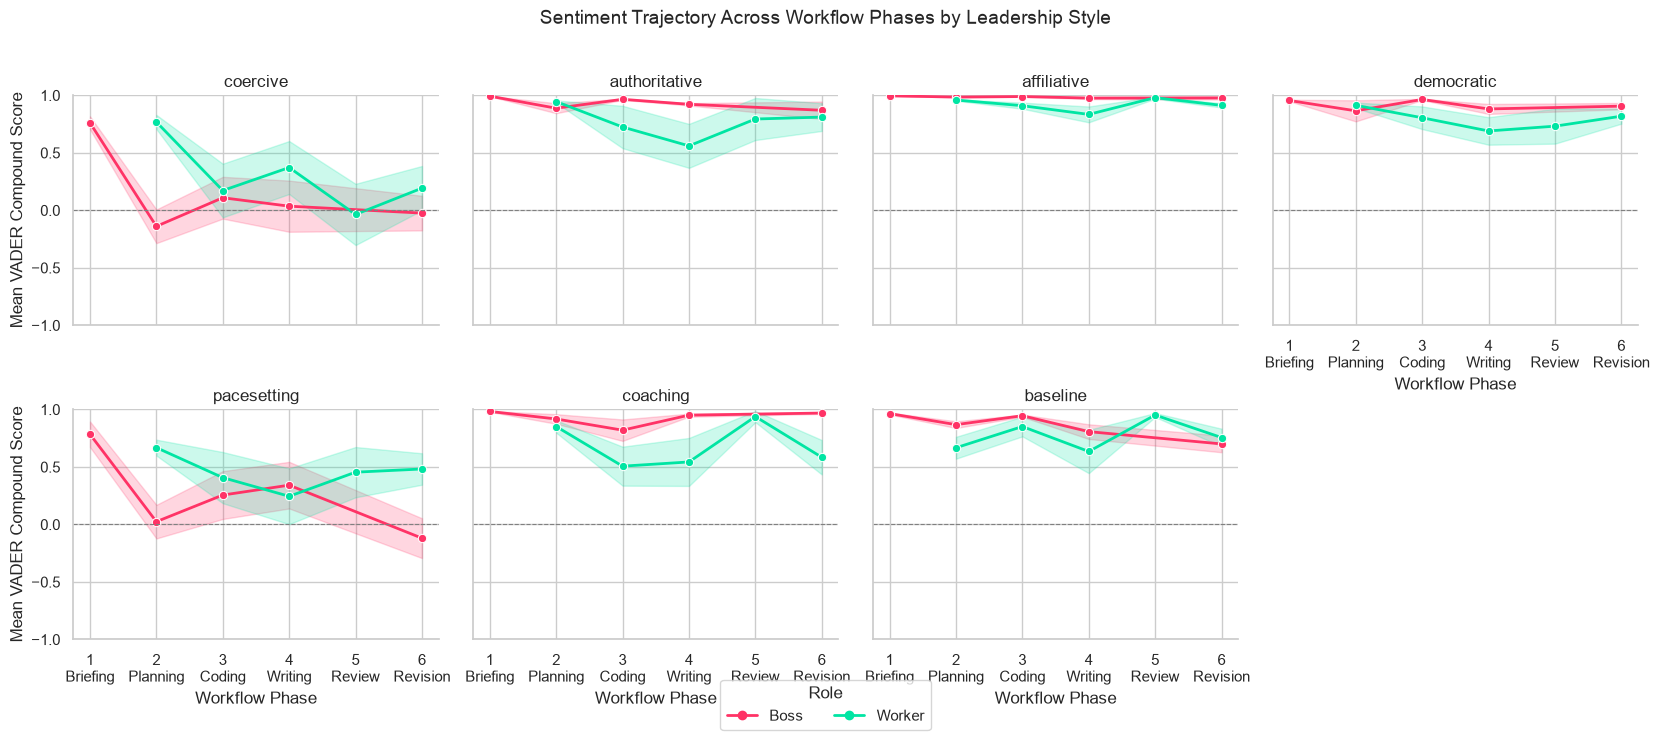

In [14]:
# Add a Boss vs. Worker role column for message-level data
df_msg_sent['Role'] = df_msg_sent['sender'].map(
    lambda s: 'Boss' if s == 'Boss' else ('Worker' if s in ['Coder', 'Writer', 'Reviewer'] else None)
)
df_phase = df_msg_sent[df_msg_sent['Role'].notna()].copy()

# Faceted line plot: one panel per leadership style, Boss vs. Worker lines
from matplotlib.lines import Line2D

g = sns.FacetGrid(df_phase, col='style', col_order=STYLE_ORDER, col_wrap=4,
                  height=3.5, aspect=1.2, sharey=True)

g.map_dataframe(sns.lineplot, x='phase', y='compound', hue='Role',
                hue_order=['Boss', 'Worker'], palette=BOSS_WORKER_COLORS,
                estimator='mean', errorbar='se', marker='o', linewidth=2, legend=False)

g.set_axis_labels('Workflow Phase', 'Mean VADER Compound Score')
g.set_titles('{col_name}')
g.fig.suptitle('Sentiment Trajectory Across Workflow Phases by Leadership Style', y=1.02)

for ax in g.axes.flat:
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(['1\nBriefing', '2\nPlanning', '3\nCoding', '4\nWriting', '5\nReview', '6\nRevision'],
                       rotation=0, ha='center')
    ax.set_ylim(-1.0, 1.0)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Single shared legend
legend_elements = [
    Line2D([0], [0], color='#FF3366', lw=2, marker='o', markersize=6, label='Boss'),
    Line2D([0], [0], color='#00E5A3', lw=2, marker='o', markersize=6, label='Worker')
]
g.fig.legend(handles=legend_elements, loc='lower center', ncol=2,
             title='Role', bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
save_fig('03_sentiment_trajectory_phases_vader')
plt.show()

## Figure 4 — Sentiment Trajectory Divergence: Boss vs. Workers

Faceted line trajectories of **VADER compound sentiment** across the 6 workflow phases, with one panel per leadership style.

- **Red line:** Boss mean sentiment.
- **Blue line:** Combined worker (Coder + Writer + Reviewer) mean sentiment.
- **Shaded area:** ±1 standard error of the mean across the 5 runs.

This reveals where friction peaks — for example, whether demanding styles create a growing sentiment gap during Review and Revision (phases 5–6), or whether warm styles keep Boss and worker lines tightly coupled.


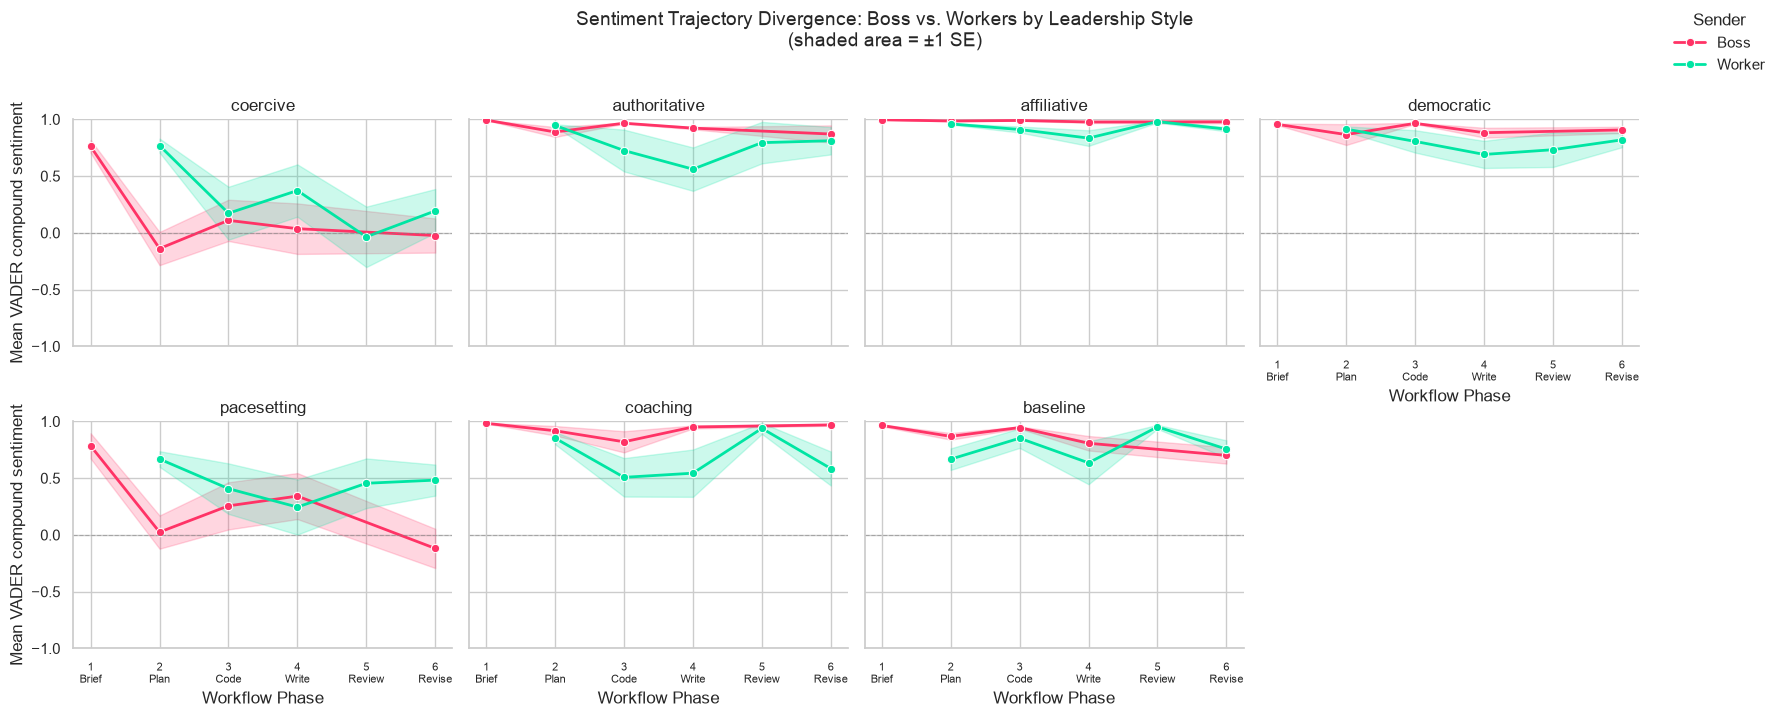

In [15]:
# Per-message scores, with each sender tagged as Boss or Worker
df_sentiment = (df_msg_sent
                .assign(run=df_msg_sent['run_dir'],
                        role=np.where(df_msg_sent['sender'] == 'Boss', 'Boss', 'Worker'))
                [['run', 'style', 'task', 'phase', 'role', 'compound']]
                .copy())

# Faceted trajectory: Boss vs Worker, 7 panels
g = sns.FacetGrid(df_sentiment, col='style', col_order=STYLE_ORDER, col_wrap=4,
                  sharey=True, sharex=True, height=3.5, aspect=1.2)

g.map_dataframe(
    sns.lineplot,
    x='phase', y='compound', hue='role',
    hue_order=['Boss', 'Worker'],
    palette=BOSS_WORKER_COLORS,
    errorbar='se',
    linewidth=2,
    marker='o',
    markersize=6
)

# Formatting
for ax in g.axes.flat:
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.set_xticklabels(['1\nBrief', '2\nPlan', '3\nCode', '4\nWrite', '5\nReview', '6\nRevise'], fontsize=8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

g.set(ylim=(-1.0, 1.0), yticks=[-1.0, -0.5, 0.0, 0.5, 1.0])
g.set_titles(col_template='{col_name}')
g.set_axis_labels('Workflow Phase', 'Mean VADER compound sentiment')
g.add_legend(title='Sender', loc='upper right')

g.fig.suptitle(
    'Sentiment Trajectory Divergence: Boss vs. Workers by Leadership Style\n(shaded area = ±1 SE)',
    fontsize=14, y=1.02
)
g.tight_layout()
save_fig('03_sentiment_trajectory_vader')
plt.show()

## Figure 5 — Phase-Level Sentiment vs. Final Survey Satisfaction

This plot overlays the **mean VADER compound sentiment** across the 6 workflow phases with the **final survey satisfaction score** for each leadership style, to see whether the emotional tone during the conversation aligns with the post-hoc worker satisfaction.

- **X-axis:** phases 1–6, plus phase 7 = post-experiment `survey_team_mean`.
- **Y-axis:** both metrics rescaled to **[-1, 1]**. VADER compound is already on this scale; the 1–5 Likert `survey_team_mean` is normalized as `(score - 3) / 2`.
- **7 colored lines:** one per leadership style.
- The dashed vertical link from phase 6 to phase 7 (across the two columns) makes it easy to spot styles whose sentiment trajectory is consistent with the final satisfaction.


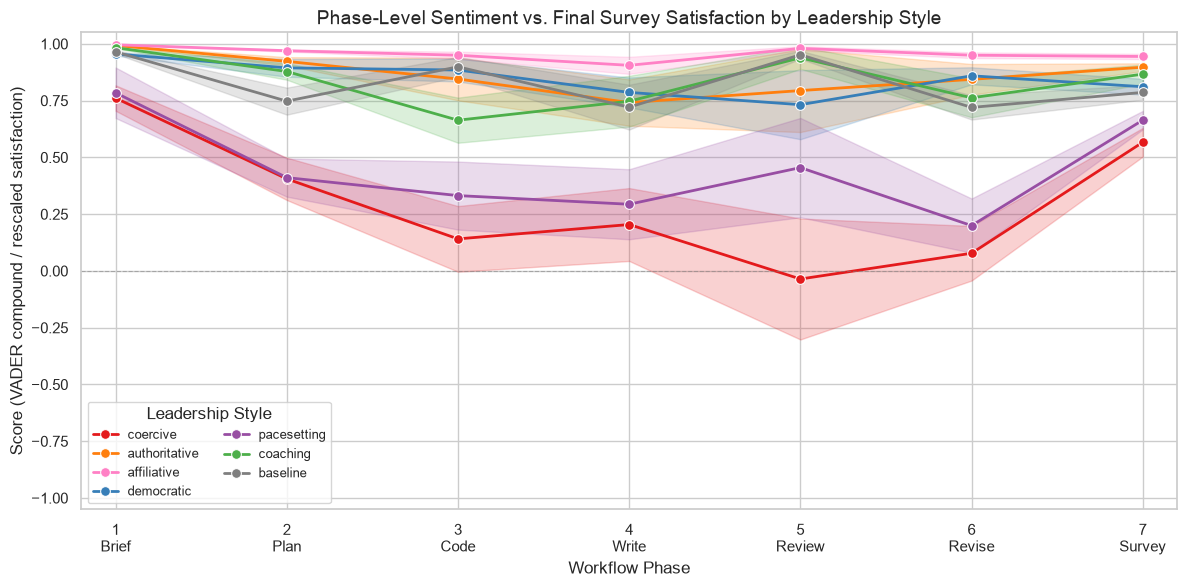

In [16]:
# Aggregate phase-level sentiment per run, and rescale final team satisfaction to [-1, 1]
df_phase_sent = (df_msg_sent
                 .dropna(subset=['phase'])
                 .assign(run=df_msg_sent['run_dir'],
                         phase=lambda d: d['phase'].astype(int),
                         score=lambda d: d['compound'])
                 [['style', 'run', 'phase', 'score']]
                 .copy())

# Final team satisfaction, rescaled from the 1-5 Likert scale to -1..1
sat_rows = []
for d in run_dirs:
    folder = os.path.basename(d)
    parts = folder.split('_')
    surv_file = os.path.join(d, 'survey_results.json')
    if os.path.exists(surv_file):
        with open(surv_file, 'r', encoding='utf-8') as f:
            surv = json.load(f)
        sat_rows.append({
            'style': parts[0],
            'run': folder,
            'phase': 7,
            'score': (surv.get('team_mean', 3.0) - 3.0) / 2.0,
        })

df_final_sat = pd.DataFrame(sat_rows)
df_combined = pd.concat([df_phase_sent, df_final_sat], ignore_index=True)
df_combined['style'] = pd.Categorical(df_combined['style'], categories=STYLE_ORDER, ordered=True)

fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=df_combined,
    x='phase', y='score', hue='style',
    hue_order=STYLE_ORDER,
    palette=STYLE_COLORS,
    estimator='mean',
    errorbar='se',
    err_style='band',
    linewidth=2,
    marker='o',
    markersize=7,
    ax=ax
)

ax.set_xlim(0.8, 7.2)
ax.set_ylim(-1.05, 1.05)
ax.set_xticks([1, 2, 3, 4, 5, 6, 7])
ax.set_xticklabels([
    '1\nBrief', '2\nPlan', '3\nCode', '4\nWrite',
    '5\nReview', '6\nRevise', '7\nSurvey'
], rotation=0, ha='center')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Workflow Phase')
ax.set_ylabel('Score (VADER compound / rescaled satisfaction)')
ax.set_title('Phase-Level Sentiment vs. Final Survey Satisfaction by Leadership Style', fontsize=14)
ax.legend(title='Leadership Style', loc='lower left', ncol=2, fontsize=9)

plt.tight_layout()
save_fig('03_phase_sentiment_vs_survey_vader')
plt.show()

## VADER Sentiment Component Breakdown by Leadership Style

Mean positive, neutral, and negative VADER probability mass per style. The three components sum to 1.0 for each message, so each stacked bar represents the full sentiment distribution.

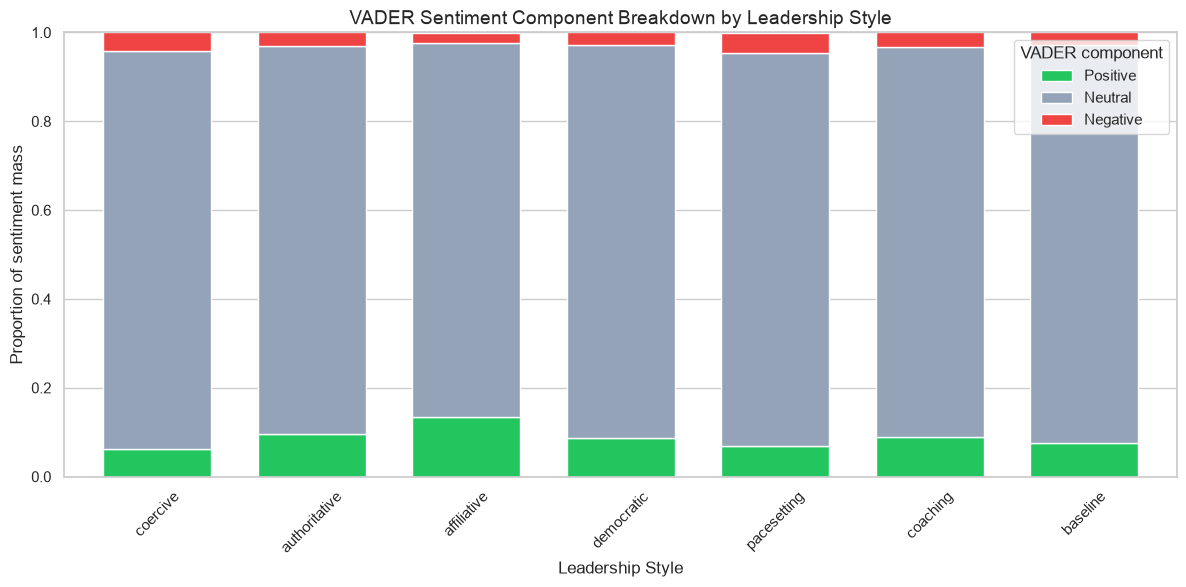

Mean VADER component mass by style:
               Positive  Neutral  Negative
style                                     
coercive         0.0619   0.8962    0.0419
authoritative    0.0950   0.8757    0.0294
affiliative      0.1353   0.8411    0.0235
democratic       0.0877   0.8832    0.0291
pacesetting      0.0692   0.8844    0.0463
coaching         0.0901   0.8772    0.0327
baseline         0.0764   0.8959    0.0277


In [17]:
fig, ax = plt.subplots(figsize=(12, 6))

comp = (df_msg_sent
        .groupby('style', observed=True)[['positive', 'neutral', 'negative']]
        .mean()
        .rename(columns={'positive': 'Positive', 'neutral': 'Neutral', 'negative': 'Negative'})
        .reindex(STYLE_ORDER))

# 100% stacked bar: green = positive, gray = neutral, red = negative
comp[['Positive', 'Neutral', 'Negative']].plot(
    kind='bar',
    stacked=True,
    color=['#22C55E', '#94A3B8', '#EF4444'],
    edgecolor='white',
    width=0.7,
    ax=ax
)

ax.set_ylim(0, 1.0)
ax.set_ylabel('Proportion of sentiment mass')
ax.set_xlabel('Leadership Style')
ax.set_title('VADER Sentiment Component Breakdown by Leadership Style', fontsize=14)
ax.legend(title='VADER component', loc='upper right')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_fig('03_vader_components')
plt.show()

print('Mean VADER component mass by style:')
print(comp.round(4).to_string())